In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Exploración de la forma tridimensional de los cúmulos más poblados

Se importa tablas.

In [2]:
clusters = pd.read_csv('../data/processed/clusters.csv')
members = pd.read_csv('../data/processed/members.csv')

Se seleccionan los cúmulos con más de mil miembros

In [3]:
num_members = 1000
largest_clusters = clusters[clusters['N'] >= num_members]

Se escoge aleatoriamente uno de los cúmulos con más de mil miembros.

In [4]:
cluster_num = np.random.randint(0, len(largest_clusters))
cluster = largest_clusters.iloc[cluster_num, :]
cluster_name = cluster['Name']
cluster_members = members[members['Name'] == cluster_name]

## Forma tridimensional del cúmulo

Para lograr esto se debe encontrar las coordenadas cartesianas de los miembros del cúmulo, esto se puede hacer con: 

\begin{align*}
    x &= d \cos{\delta} \cos{\alpha} \\
    y &= d \cos{\delta} \sin{\alpha} \\
    z &= d \sin{\delta}
\end{align*}

donde $d$ es la distancia a la estrella, $\delta$ y $\alpha$ son la declinación y la ascención recta de la respectiva estrella.

Se calculan las coordenadas cartesianas del punto más denso del cúmulo.

In [5]:
d0 = cluster['dist50']
ra0 = np.radians(cluster['RA_ICRS'])
dec0 = np.radians(cluster['DE_ICRS'])

In [6]:
x0 = d0 * np.cos(dec0) * np.cos(ra0)
y0 = d0 * np.cos(dec0) * np.sin(ra0)
z0 = d0 * np.sin(dec0)

Se calculan las coordenadas cartesianas de los miembros del cúmulo.

In [7]:
ds = cluster_members['r_med_photogeo'].values
ras = np.radians(cluster_members['RA_ICRS'].values)
decs = np.radians(cluster_members['DE_ICRS'].values)

In [8]:
xs = ds * np.cos(decs) * np.cos(ras)
ys = ds * np.cos(decs) * np.sin(ras)
zs = ds * np.sin(decs)

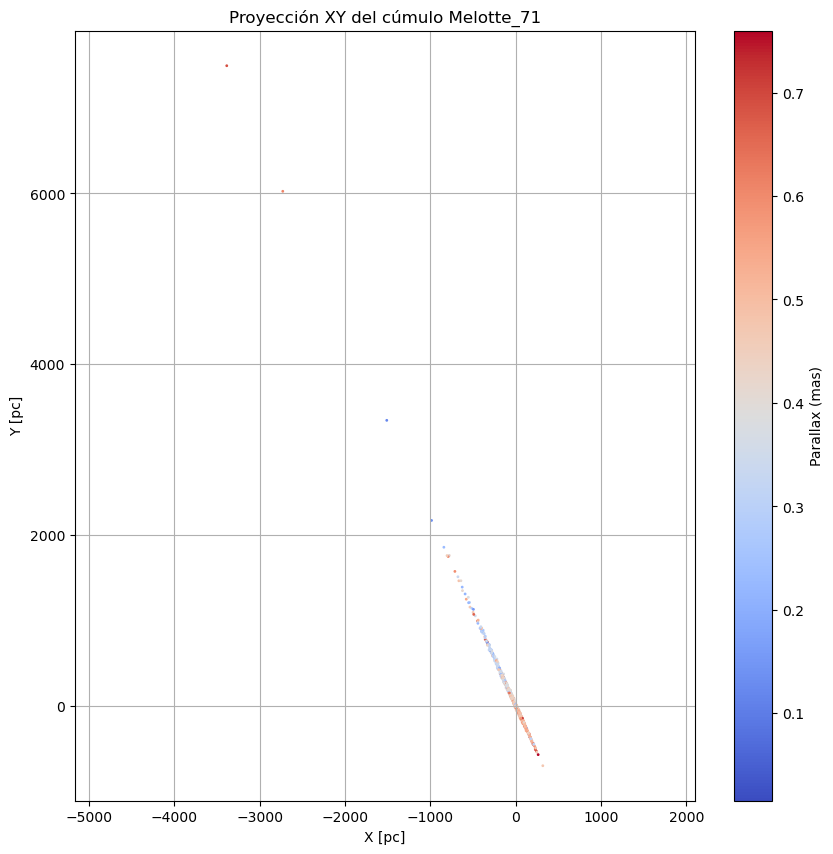

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))

sc = ax.scatter(xs - x0, ys - y0, c=cluster_members['Plx'], cmap='coolwarm', s=1)
fig.colorbar(sc, label='Parallax (mas)')
ax.set_xlabel('X [pc]')
ax.set_ylabel('Y [pc]')
ax.set_title(f'Proyección XY del cúmulo {cluster_name}')
ax.grid()

plt.axis('equal')
plt.show()

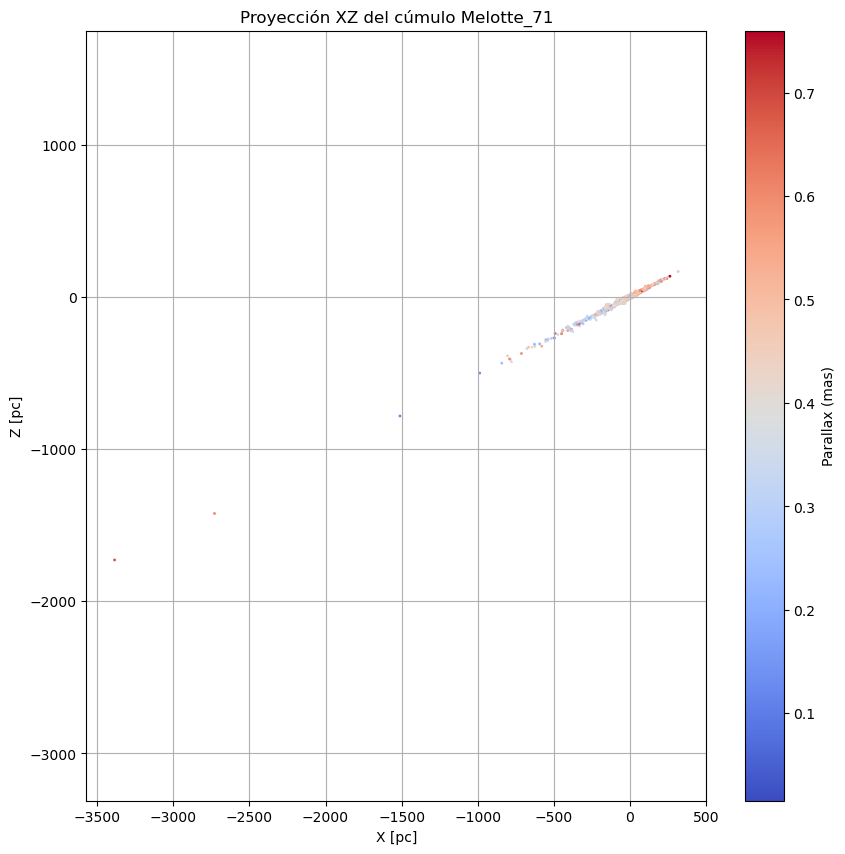

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))

sc = ax.scatter(xs - x0, zs - z0, c=cluster_members['Plx'], cmap='coolwarm', s=1)
fig.colorbar(sc, label='Parallax (mas)')
ax.set_xlabel('X [pc]')
ax.set_ylabel('Z [pc]')
ax.set_title(f'Proyección XZ del cúmulo {cluster_name}')
ax.grid()

plt.axis('equal')
plt.show()

Se observa que hay una distorsión en la línea de la visual.